HW #2 - Data Acquisition, Processing, and Communication

In [2]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from shapely.geometry import box, Polygon
import os
import sys
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
import importlib
from supporting_scripts import mapping
from supporting_scripts import hw2_data
from supporting_scripts import hw2_analysis
from supporting_scripts import hw2_metrics
warnings.filterwarnings("ignore")

Load Streamflow Data

In [3]:
usgs_gage_id = "13042500"  # NWIS id for Henry's Fork at the mouth of Island Park Reservoir
WY = 2025  # Water Year to analyze.

# Get streamflow information using the NWIS id for the gage.
streamflow = hw2_data.fetch_streamflow(usgs_gage_id)

Retrieving data for Site: 13042500 from 1980-01-01 to 2026-03-31...


In [4]:
basinname = "IslandParkReservoir"
basin, site_feature, upstream_network = hw2_data.load_basin_and_network(
     usgs_gage_id, basinname
)

In [5]:
# Clean dataset 13042500.
cleaned = hw2_data.prepare_streamflow_dataframe(streamflow)
cleaned.head()

,site_no,flow_cms
Date,,
1980-01-01,13042500,3.511283
1980-01-02,13042500,3.511283
1980-01-03,13042500,3.511283
1980-01-04,13042500,3.511283
1980-01-05,13042500,3.511283


Load SWE Data

In [6]:
# # Load SNOTEL/SWE data
# Data source: Gagliano, E. (2024). snotel_ccss_stations v1.0
requested_sites = ["546_ID_SNTL", "860_ID_SNTL"]
snotel_data = hw2_data.load_requested_snotel_data(requested_sites)

Loaded 546_ID_SNTL: 16252 rows
Loaded 860_ID_SNTL: 16252 rows


In [7]:
# # Create geodataframe for target SNOTEL stations
target_codes = {"546_ID_SNTL", "860_ID_SNTL"}
all_stations_gdf, gdf_in_bbox = hw2_data.load_station_metadata(target_codes)
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,546_ID_SNTL,Island Park,SNOTEL,1917.192017,44.420300,-111.385117,Idaho,170402020601,12TVQ,None,1979-10-01,2026-03-30,True,POINT (-111.38512 44.4203)
1,860_ID_SNTL,White Elephant,SNOTEL,2350.008057,44.532669,-111.410851,Idaho,170402020305,12TVQ,Idaho-Bitterroot Rocky Mountains,1979-10-01,2026-03-30,True,POINT (-111.41085 44.53267)


In [17]:
# Compute historical averages for April 1 for SWE and Streamflow data. This will be used for comparison with the April 1, 2025 values.
import io
from contextlib import redirect_stdout

with redirect_stdout(io.StringIO()):
    april1_summary, april1_2025 = hw2_metrics.summarize_april1_swe_streamflow(
        snotel_data,
        cleaned,
        site_code="546_ID_SNTL",
        target_date="2025-04-01",
    )

# Explicitly use April 1 values across all years in the dataset
swe_april1_all_years_avg = april1_summary["swe_april1"].mean()
streamflow_april1_all_years_avg = april1_summary["streamflow_april1_cms"].mean()

april1_display = pd.DataFrame(
    {
        "Metric": [
            "SWE April 1 all-years average",
            "Streamflow April 1 all-years average (cms)",
            "SWE April 1, 2025",
            "Streamflow April 1, 2025 (cms)",
        ],
        "Value": [
            swe_april1_all_years_avg,
            streamflow_april1_all_years_avg,
            april1_2025["swe_april1"],
            april1_2025["streamflow_april1_cms"],
        ],
    }
)

april1_display

,Metric,Value
0,SWE April 1 all-years average,0.364836
1,Streamflow April 1 all-years average (cms),9.953109
2,"SWE April 1, 2025",0.332700
3,"Streamflow April 1, 2025 (cms)",6.541181


Area of Interest

In [9]:
# Create map. If prompted, trust the notebook: jupyter trust HW2.ipynb
from supporting_scripts import mapping

mapping.basin_mapping(basin, site_feature)
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

SWE Analysis for SNOTEL Sites

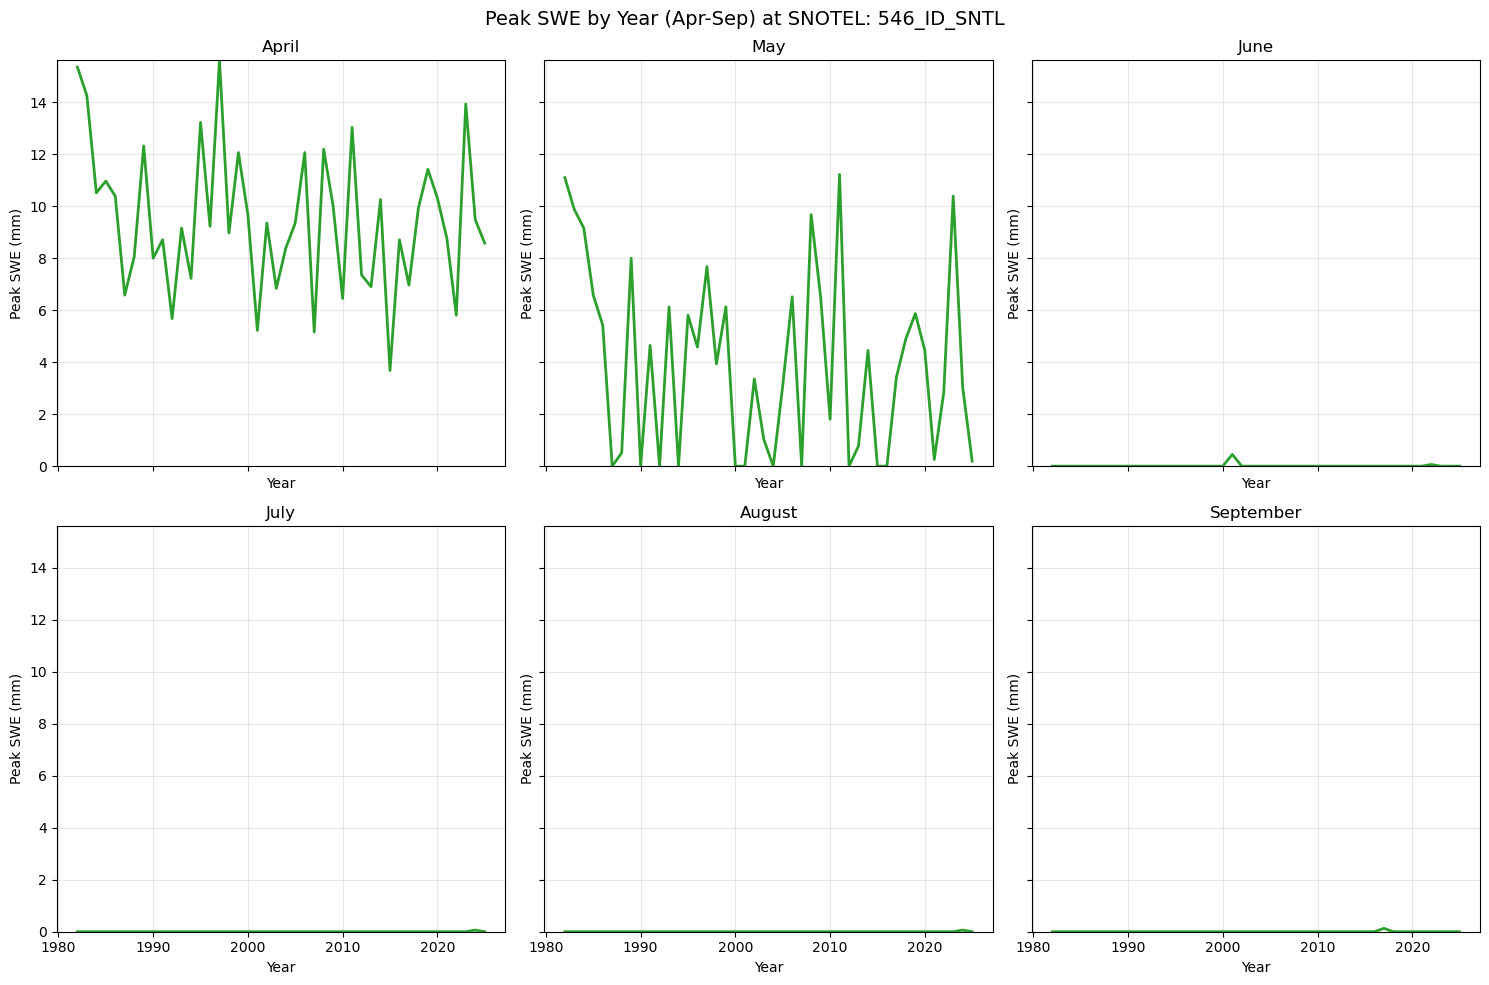

In [10]:
# Plot peak SWE by year for Apr-Sep (6 subplots)
site_code = '546_ID_SNTL'
hw2_analysis.plot_peak_swe_by_month(snotel_data, site_code)

USGS Streamflow Analysis

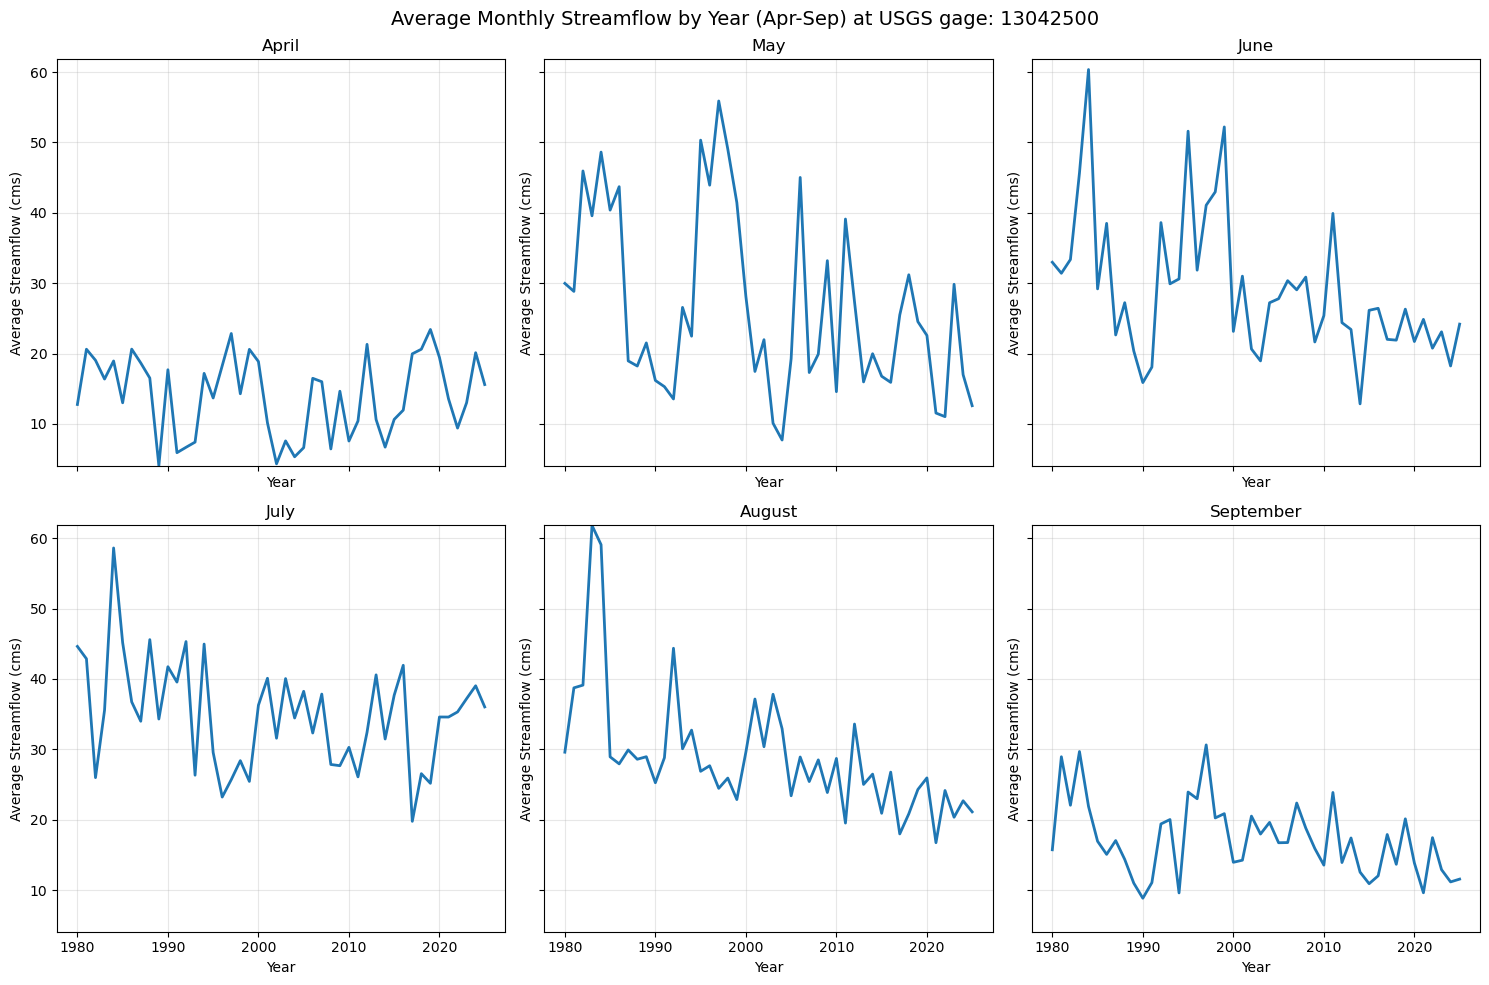

In [11]:
# Plot monthly mean streamflow for Apr-Sep by year (x-axis = year)
hw2_analysis.plot_monthly_streamflow(cleaned, usgs_gage_id)

Compare and Contrast Peak SWE with Streamflow

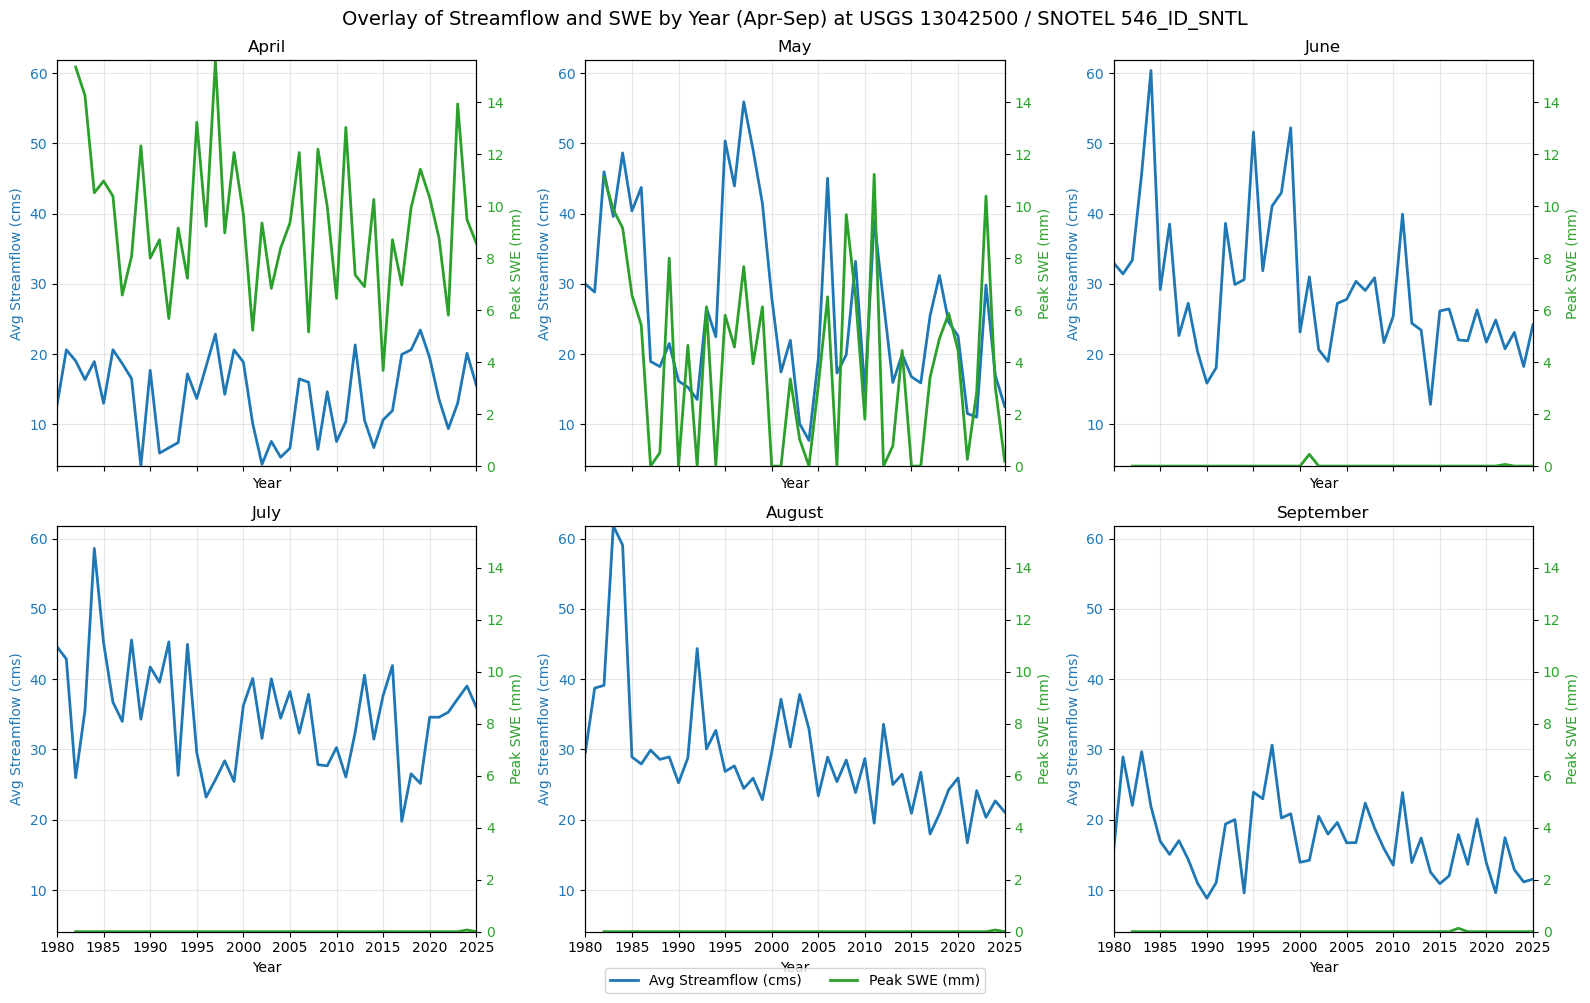

In [12]:
# Overlay streamflow and peak SWE by year (Apr-Sep) in the same 6 subplots
site_code = '546_ID_SNTL'
hw2_analysis.plot_streamflow_swe_overlay(cleaned, snotel_data, site_code, usgs_gage_id)